In [ ]:
install.packages("vctrs")
install.packages(c("dplyr", "tidyr", "ggplot2", "readr"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(readr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
data <- read_csv("/content/Disease and symptoms dataset.csv")

Rows: 246945 Columns: 378
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): diseases
dbl (377): anxiety and nervousness, depression, shortness of breath, depress...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
dim(data)

[1] 246945    378

In [ ]:
str(data[, 1:10])

tibble [246,945 × 10] (S3: tbl_df/tbl/data.frame)
 $ diseases                        : chr [1:246945] "panic disorder" "panic disorder" "panic disorder" "panic disorder" ...
 $ anxiety and nervousness         : num [1:246945] 1 0 1 1 1 0 1 0 1 1 ...
 $ depression                      : num [1:246945] 0 0 1 0 1 0 0 0 0 1 ...
 $ shortness of breath             : num [1:246945] 1 1 1 0 0 1 0 0 0 1 ...
 $ depressive or psychotic symptoms: num [1:246945] 1 1 1 1 0 1 0 1 1 0 ...
 $ sharp chest pain                : num [1:246945] 0 0 0 0 0 0 0 0 0 0 ...
 $ dizziness                       : num [1:246945] 0 1 1 1 0 0 0 0 1 0 ...
 $ insomnia                        : num [1:246945] 0 1 1 1 1 1 0 1 1 0 ...
 $ abnormal involuntary movements  : num [1:246945] 0 0 0 1 1 0 0 1 0 1 ...
 $ chest tightness                 : num [1:246945] 1 0 0 0 1 0 0 1 1 0 ...


In [ ]:
total_na <- sum(is.na(data)) # missing values
total_na

[1] 0

In [ ]:
colSums(is.na(data))[1:20] # row wise missing values

diseases          anxiety and nervousness 
                               0                                0 
                      depression              shortness of breath 
                               0                                0 
depressive or psychotic symptoms                 sharp chest pain 
                               0                                0 
                       dizziness                         insomnia 
                               0                                0 
  abnormal involuntary movements                  chest tightness 
                               0                                0 
                    palpitations              irregular heartbeat 
                               0                                0 
                  breathing fast                     hoarse voice 
                               0                                0 
                     sore throat              difficulty speaking 
                               0                                0 
                           cough                 nasal congestion 
                               0                                0 
                 throat swelling               diminished hearing 
                               0                                0

In [ ]:
sum(duplicated(data)) # check for duplicate rows

[1] 57298

In [ ]:
unique(unlist(data[, 2:6])) # binary value validation

[1] 1 0

In [ ]:
disease_count <- sort(table(data$diseases), decreasing = TRUE)
head(disease_count, 10)


                      cystitis                  nose disorder 
                          1219                           1218 
                    vulvodynia complex regional pain syndrome 
                          1218                           1217 
                   spondylosis  conjunctivitis due to allergy 
                          1216                           1215 
                   esophagitis                   hypoglycemia 
                          1215                           1215 
     peripheral nerve disorder                   vaginal cyst 
                          1215                           1215 

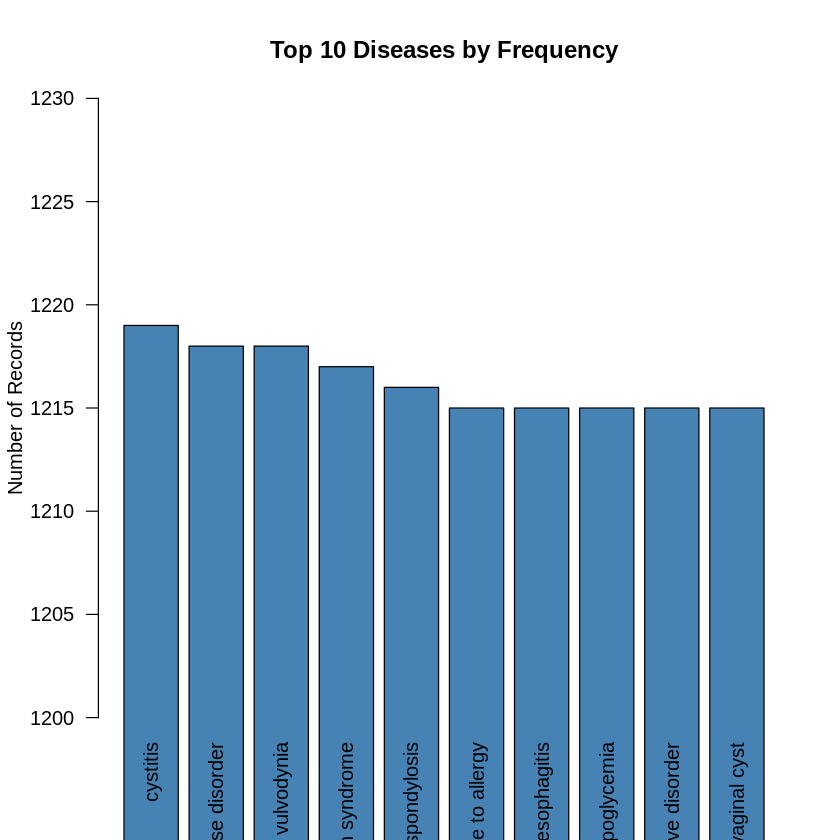

In [ ]:
top_diseases <- head(disease_count, 10)

barplot(
  top_diseases,
  las = 2,
  col = "steelblue",
  main = "Top 10 Diseases by Frequency",
  ylab = "Number of Records",
  ylim = c(1200, 1230)   # zoom into your data range
)


In [ ]:
symptom_presence_count <- colSums(data[, -1] == 1)

In [ ]:
top_symptoms <- sort(symptom_presence_count, decreasing = TRUE)[1:10]
top_symptoms


sharp abdominal pain             vomiting             headache 
               32307                27874                24719 
               cough     sharp chest pain               nausea 
               24296                24016                23687 
           back pain  shortness of breath                fever 
               21809                21346                20394 
           dizziness 
               17272

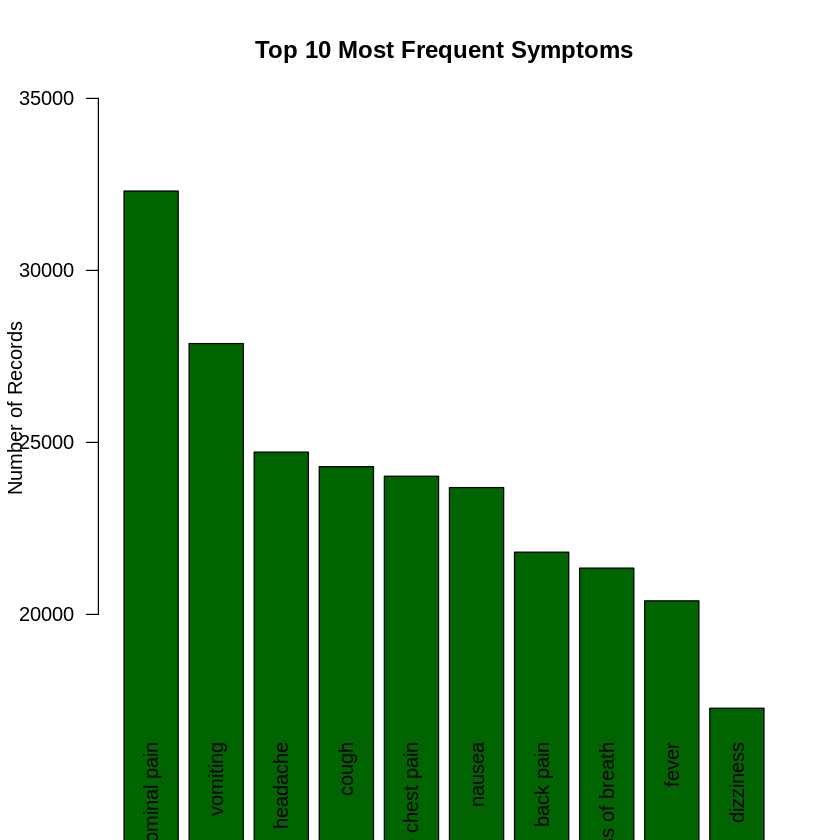

In [ ]:
barplot(
  top_symptoms,
  las = 2,
  col = "darkgreen",
  main = "Top 10 Most Frequent Symptoms",
  ylab = "Number of Records",
  ylim = c(17000, 35000)
)


In [ ]:
avg_symptoms <- mean(rowSums(data[, -1] == 1))
avg_symptoms


[1] 5.332851

In [ ]:
set.seed(1)
sample_rows <- data[sample(nrow(data), 5000), ]

symptom_count_sample <- rowSums(sample_rows[, -1] == 1)

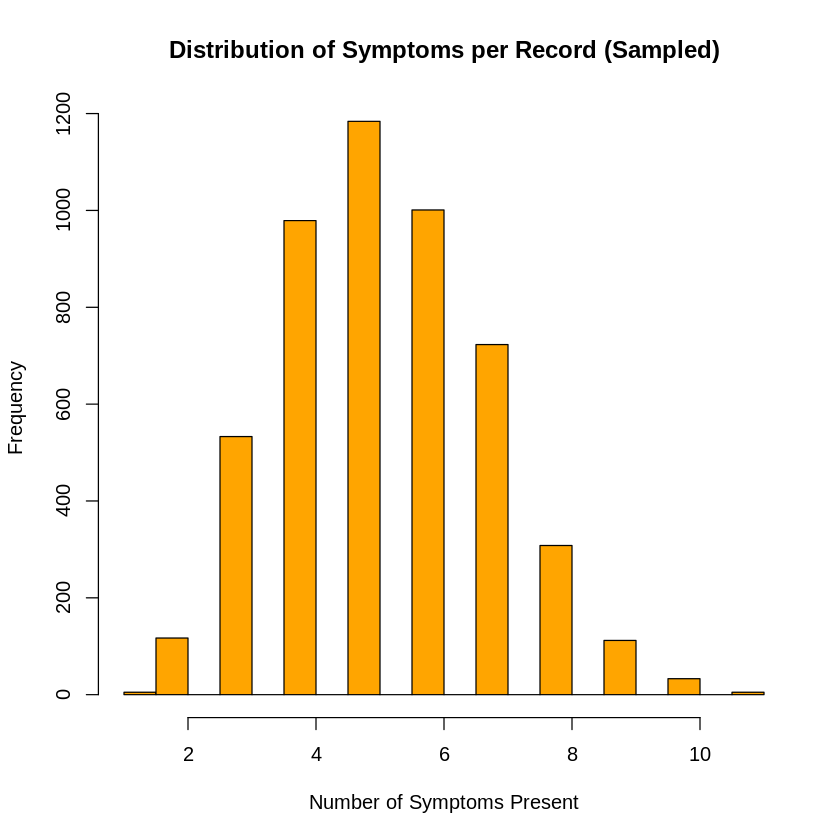

In [ ]:
hist(
  symptom_count_sample,
  breaks = 30,
  col = "orange",
  main = "Distribution of Symptoms per Record (Sampled)",
  xlab = "Number of Symptoms Present"
)


In [ ]:
cat("Rows:", nrow(data), "\n")
cat("Columns:", ncol(data), "\n")
cat("Missing values:", sum(is.na(data)), "\n")
cat("Duplicate rows:", sum(duplicated(data)), "\n")
cat("Unique diseases:", length(unique(data$diseases)), "\n")
cat("Avg symptoms per record:", avg_symptoms, "\n")


Rows: 246945 
Columns: 378 
Missing values: 0 


In [ ]:
disease_count <- sort(table(data$diseases), decreasing = TRUE)

head(disease_count, 15)


ERROR: Error in data$diseases: object of type 'closure' is not subsettable


In [ ]:
summary(disease_count)


Number of cases in table: 246945 
Number of factors: 1 

In [ ]:
disease_symptom_avg <- aggregate(
  rowSums(data[, -1] == 1),
  by = list(data$diseases),
  FUN = mean
)

colnames(disease_symptom_avg) <- c("Disease", "Avg_Symptoms")

head(disease_symptom_avg)


,Disease,Avg_Symptoms
,<chr>,<dbl>
1,abdominal aortic aneurysm,4.144928
2,abdominal hernia,5.825553
3,abscess of nose,4.682759
4,abscess of the lung,3.105263
5,abscess of the pharynx,4.715543
6,acanthosis nigricans,2.966667


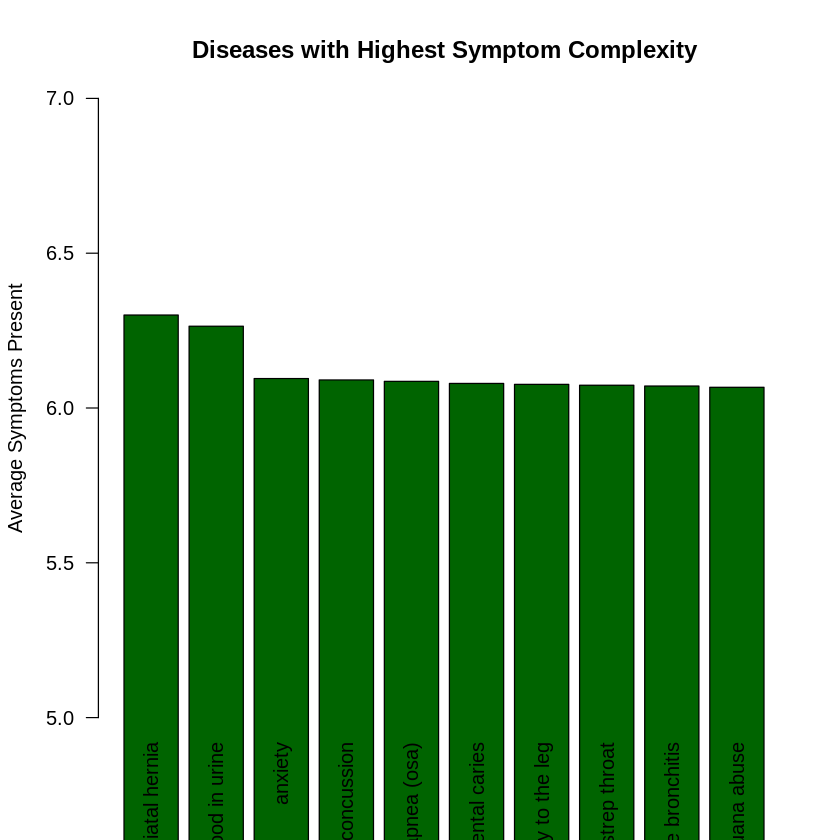

In [ ]:
top_complex <- disease_symptom_avg[
  order(-disease_symptom_avg$Avg_Symptoms), ][1:10, ]

barplot(
  top_complex$Avg_Symptoms,
  names.arg = top_complex$Disease,
  las = 2,
  col = "darkgreen",
  main = "Diseases with Highest Symptom Complexity",
  ylab = "Average Symptoms Present",
  ylim = c(5.0,7.0)
)


In [ ]:
symptom_variance <- apply(data[, -1], 2, var)

In [ ]:
top_var_symptoms <- sort(symptom_variance, decreasing = TRUE)[1:10]
top_var_symptoms

sharp abdominal pain             vomiting             headache 
          0.11371154           0.10013490           0.09007972 
               cough     sharp chest pain               nausea 
          0.08870678           0.08779475           0.08671982 
           back pain  shortness of breath                fever 
          0.08051596           0.07896869           0.07576518 
           dizziness 
          0.06505098

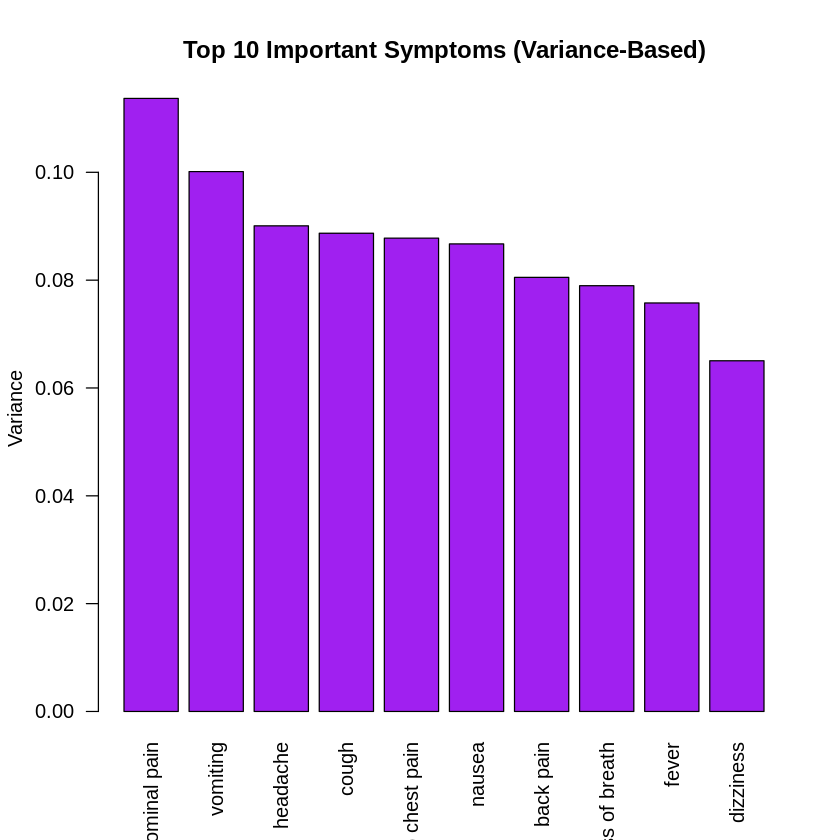

In [ ]:
barplot(
  top_var_symptoms,
  las = 2,
  col = "purple",
  main = "Top 10 Important Symptoms (Variance-Based)",
  ylab = "Variance"
)


In [ ]:
symptom_count <- rowSums(data[, -1] == 1)

disease_density <- aggregate(
  symptom_count,
  by = list(data$diseases),
  FUN = mean
)

colnames(disease_density) <- c("Disease", "Avg_Symptoms")


In [ ]:
top_complex_diseases <- disease_density[
  order(-disease_density$Avg_Symptoms), ][1:10, ]
top_complex_diseases

,Disease,Avg_Symptoms
,<chr>,<dbl>
324,hiatal hernia,6.300221
691,temporary or benign blood in urine,6.264214
45,anxiety,6.095159
140,concussion,6.090680
485,obstructive sleep apnea (osa),6.086120
174,dental caries,6.079325
382,injury to the leg,6.076285
676,strep throat,6.073554
12,acute bronchitis,6.070899


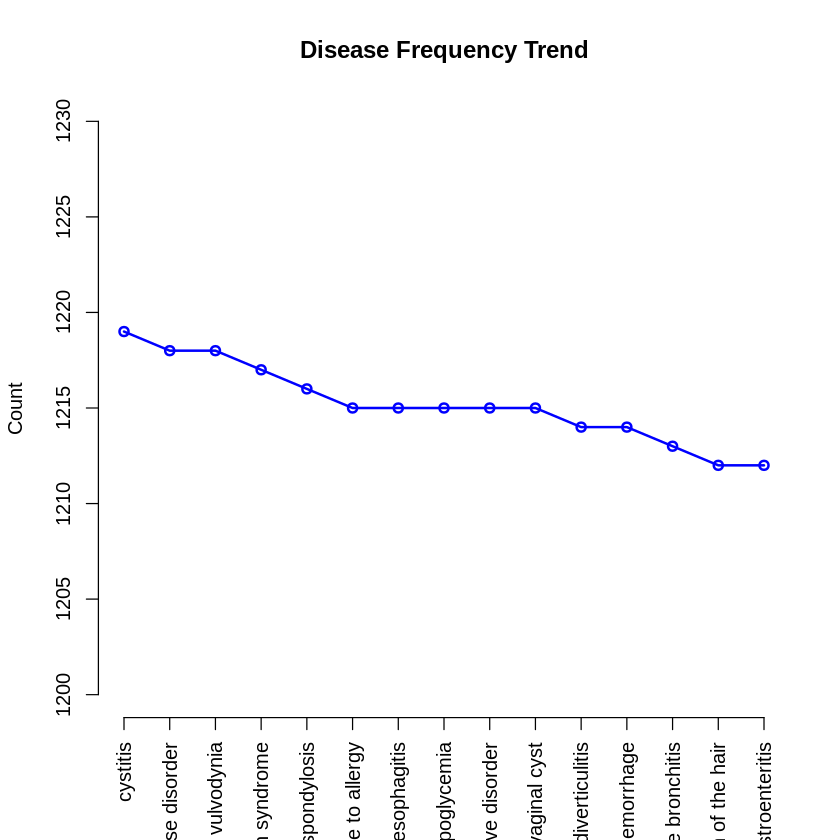

In [ ]:
top_diseases <- sort(table(data$diseases), decreasing = TRUE)[1:15]

plot(
  top_diseases,
  type = "o",
  col = "blue",
  xaxt = "n",
  main = "Disease Frequency Trend",
  ylab = "Count",
  ylim = c(1200,1230)
)

axis(1, at = 1:15, labels = names(top_diseases), las = 2)


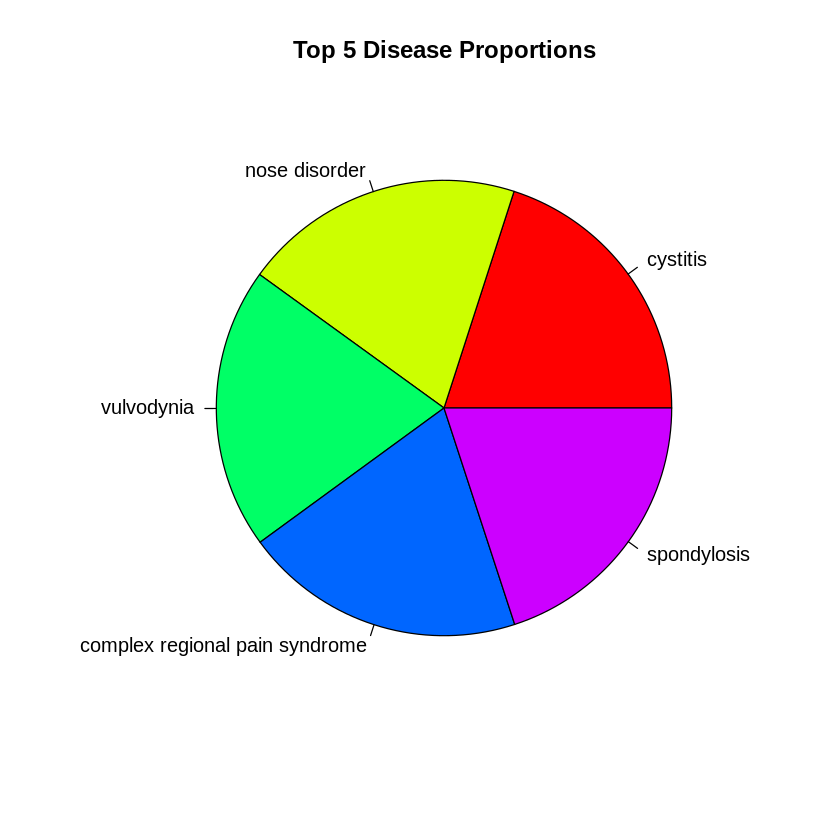

In [ ]:
top5 <- sort(table(data$diseases), decreasing = TRUE)[1:5]

pie(
  top5,
  col = rainbow(5),
  main = "Top 5 Disease Proportions"
)


In [ ]:
# Binary presence matrix
symptom_matrix <- data[, -1] == 1

# Aggregate by disease (MEAN symptom presence)
disease_features <- aggregate(
  symptom_matrix,
  by = list(data$diseases),
  FUN = mean
)

# Rename disease column
colnames(disease_features)[1] <- "Disease"

dim(disease_features)


[1] 773 378

In [ ]:
row_names <- disease_features$Disease
cluster_data <- as.matrix(disease_features[, -1])
rownames(cluster_data) <- row_names

In [ ]:
set.seed(1)
k <- 4

In [ ]:
kmeans_model <- kmeans(cluster_data, centers = k, nstart = 10)

In [ ]:
rownames(disease_clusters) <- NULL
head(disease_clusters)


,Disease,Cluster
,<chr>,<int>
1,abdominal aortic aneurysm,1
2,abdominal hernia,1
3,abscess of nose,2
4,abscess of the lung,4
5,abscess of the pharynx,2
6,acanthosis nigricans,3


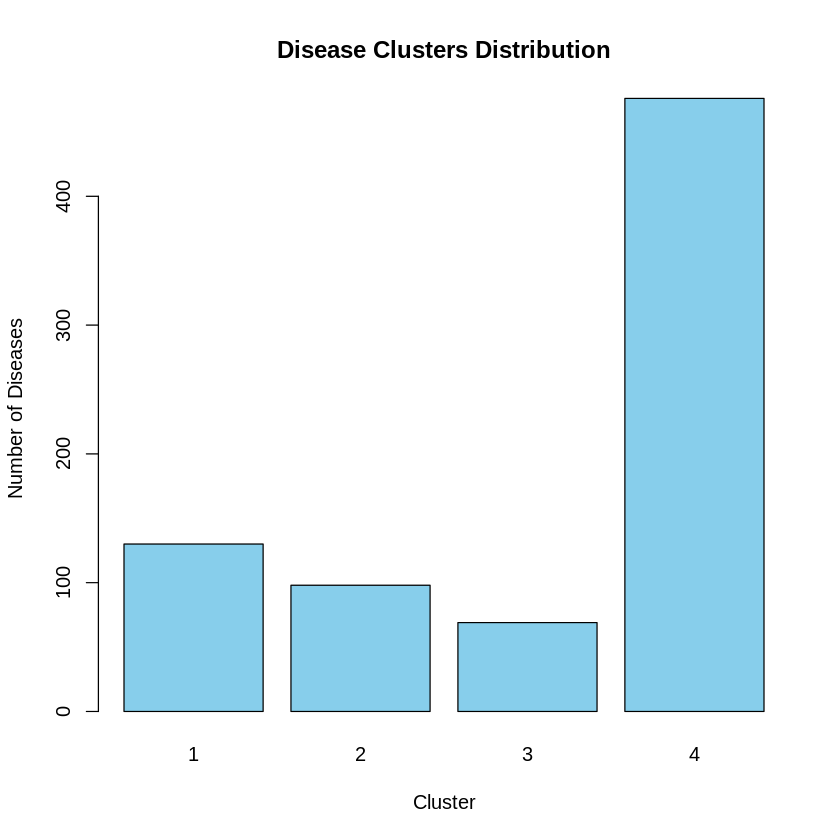

In [ ]:
cluster_count <- table(disease_clusters$Cluster)

barplot(
  cluster_count,
  col = "skyblue",
  main = "Disease Clusters Distribution",
  xlab = "Cluster",
  ylab = "Number of Diseases"
)
